## Deep Learning

### Chapter 13: Store Sales Timeseries (Recurrent Neural Networks + LTSM + GRU)

Dataset Link: [store sales forecasting](https://drive.google.com/drive/folders/1gBb6NTi62HUMKgeJgVKmHYUdmerY4TmF?usp=drive_link)

Original Source: [Kaggle](https://www.kaggle.com/competitions/store-sales-time-series-forecasting/data)

#### **0.1. Setup File Paths**

In [31]:
base_data_path = "store sales forecasting"

#### **0.2. Import required libraries**

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [33]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, GRU, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

#### **0.3. Helper Functions**

In [34]:
# Plots the sales trend over time for a given DataFrame.
def plot_sales_trend_over_time(df_plot_train):
    plt.figure(figsize=(15, 5))
    sns.lineplot(x='date', y='sales', data=df_plot_train)
    plt.title('Sales Over Time')
    plt.xlabel('Date')
    plt.ylabel('Sales')
    plt.grid(True)
    plt.show()

# Plots the average monthly sales for a given DataFrame.
def plot_average_monthly_sales(df_plot_train):
    df_plot_train['month'] = df_plot_train['date'].dt.month
    plt.figure(figsize=(12, 6))
    sns.barplot(x='month', y='sales',
                data=df_plot_train.groupby('month')['sales'].mean().reset_index())
    plt.title('Average Monthly Sales')
    plt.xlabel('Month')
    plt.ylabel('Average Sales')
    plt.grid(axis='y')
    plt.show()

# Plots the average sales by day of the week for a given DataFrame.
def plot_average_sales_by_day_of_week(df_plot_train):
    df_plot_train['dayofweek_name'] = df_plot_train['date'].dt.day_name()
    weekday_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday',
                     'Friday', 'Saturday', 'Sunday']
    df_weekday_sales = (df_plot_train.groupby('dayofweek_name')['sales'].mean().reindex(weekday_order).reset_index())
    plt.figure(figsize=(12, 6))
    sns.barplot(x='dayofweek_name', y='sales', data=df_weekday_sales, palette='viridis', hue='dayofweek_name', legend=False)
    plt.title('Average Sales by Day of Week')
    plt.xlabel('Day of Week')
    plt.ylabel('Average Sales')
    plt.grid(axis='y')
    plt.show()

# Plots the impact of promotions by product family for a given DataFrame.
def plot_promotion_impact_by_family(df_plot_train):
    df_plot_train['is_on_promotion'] = (df_plot_train['onpromotion'] > 0)
    promo_effect_per_family = (df_plot_train.groupby(['family', 'is_on_promotion'])['sales'].mean().reset_index())
    plt.figure(figsize=(18, 8))
    sns.barplot(x='family', y='sales', hue='is_on_promotion', data=promo_effect_per_family, palette='Paired')
    plt.title('Promotion Impact by Product Family')
    plt.xlabel('Product Family')
    plt.ylabel('Average Sales')
    plt.xticks(rotation=90)
    plt.legend(title='Promotion', labels=['No', 'Yes'])
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

# Plots the training and validation loss from a Keras training history object.
def plot_training_validation_loss(history, title_prefix=''):
    plt.figure(figsize=(12, 5))
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title(f'{title_prefix}Training and Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)
    plt.show()

# Plots the training and validation Mean Absolute Error (MAE) from a Keras training history object.
def plot_training_validation_mae(history, title_prefix=''):
    plt.figure(figsize=(12, 5))
    plt.plot(history.history['mae'], label='Training MAE')
    plt.plot(history.history['val_mae'], label='Validation MAE')
    plt.title(f'{title_prefix}Training and Validation MAE')
    plt.xlabel('Epoch')
    plt.ylabel('MAE')
    plt.legend()
    plt.grid(True)
    plt.show()

# Plots actual vs. predicted sales.
def plot_actual_vs_predicted_sales(y_actual, y_predicted, title='Actual vs Predicted Sales', label_predicted='Predicted Sales'):
    plt.figure(figsize=(15, 6))
    plt.plot(y_actual, label='Actual Sales')
    plt.plot(y_predicted, label=label_predicted)
    plt.title(title)
    plt.xlabel('Time Index')
    plt.ylabel('Sales')
    plt.legend()
    plt.grid(True)
    plt.show()

# Plots a zoomed-in section of actual vs. predicted sales.
def plot_actual_vs_predicted_sales_zoomed(y_actual, y_predicted, start_idx, end_idx, title='Actual vs Predicted Sales (Zoomed)', label_predicted='Predicted Sales'):
    plt.figure(figsize=(15, 6))
    plt.plot(y_actual[start_idx:end_idx], label='Actual Sales')
    plt.plot(y_predicted[start_idx:end_idx], label=label_predicted)
    plt.title(title)
    plt.xlabel('Time Index')
    plt.ylabel('Sales')
    plt.legend()
    plt.grid(True)
    plt.show()

#### **1.1. Load and Explore the Data**

In [35]:
import pandas as pd
import os

file_path = os.path.join(base_data_path, "train.csv")

df = pd.read_csv(file_path).set_index('id')

print("Number of samples:", len(df))

Number of samples: 3000888


In [36]:
features = ["date", "store_nbr", "family", "onpromotion"]
target = "sales"

In [37]:
print("From", df["date"].min(), "to", df["date"].max())

From 2013-01-01 to 2017-08-15


In [38]:
print("Number of stores:", df["store_nbr"].nunique())
print("Number of product families:", df["family"].nunique())

Number of stores: 54
Number of product families: 33


In [39]:
print(df.groupby("family")["sales"].mean().sort_values(ascending=False).head(10))

family
GROCERY I        3776.972100
BEVERAGES        2385.793151
PRODUCE          1349.352123
CLEANING         1072.416744
DAIRY             709.154889
BREAD/BAKERY      463.336254
POULTRY           350.532292
MEATS             341.849965
PERSONAL CARE     270.432513
DELI              265.135067
Name: sales, dtype: float64


In [40]:
result = (df.groupby(["store_nbr", "family"]).agg({"sales": "mean"}).sort_values("sales",
                                                                                 ascending=False))
print(result.head(10))

                           sales
store_nbr family                
44        GROCERY I  9730.436483
45        GROCERY I  9708.878439
47        GROCERY I  9212.902904
46        GROCERY I  8516.782660
44        BEVERAGES  7967.849762
3         GROCERY I  7702.178130
48        GROCERY I  7619.355173
45        BEVERAGES  6751.990499
3         BEVERAGES  6740.848575
49        GROCERY I  6584.311164


#### **1.2. Prepare the Data**

Data Quality Inspection

In [41]:
# Check missing values
print('Number of missing values:', df.isnull().sum().sum())
# Check duplicated rows
print('Number of duplicated rows:', df.duplicated().sum())

Number of missing values: 0
Number of duplicated rows: 0


Convert and Sort Dates

In [42]:
# Convert date column to datetime
df['date'] = pd.to_datetime(df['date'])
# Sort chronologically
df = df.sort_values('date')

Checking Sales Values

In [43]:
print('Number of negative sales values:', (df['sales'] < 0).sum())
print('Number of missing sales values:', df['sales'].isnull().sum())

print('\nMissing values in selected columns:')
print(df.isnull().sum())

Number of negative sales values: 0
Number of missing sales values: 0

Missing values in selected columns:
date           0
store_nbr      0
family         0
sales          0
onpromotion    0
dtype: int64


Splitting Data by Time



This method ensures that the models are trained on past data and evaluated on future data, which is crucial for time-series forecasting to avoid data leakage and simulate real-world performance.

In [44]:
def split_data(df_input, train_ratio=0.7, val_ratio=0.15):
    train_size = int(len(df_input) * train_ratio)
    val_size = int(len(df_input) * val_ratio)

    df_train = df_input.iloc[:train_size].copy()
    df_val = df_input.iloc[train_size: train_size + val_size].copy()

    df_test = df_input.iloc[train_size + val_size:].copy()

    print('+ Number of training samples:', len(df_train))
    print('+ Number of validation samples:', len(df_val))
    print('+ Number of testing samples:', len(df_test))

    print('\nTrain:', df_train['date'].min(), '->', df_train['date'].max())
    print('Validation:', df_val['date'].min(), '->', df_val['date'].max())
    print('Test:', df_test['date'].min(), '->', df_test['date'].max())

    return df_train, df_val, df_test

Scaling Numerical Features

In [45]:
def scale_data(df_train_input, df_val_input, df_test_input, features_to_scale):
  scaler = StandardScaler()

  df_train_scaled = df_train_input.copy()
  df_val_scaled = df_val_input.copy()
  df_test_scaled = df_test_input.copy()

  for feature in features_to_scale:
    if feature in df_train_scaled.columns:
      df_train_scaled.loc[:, feature] = scaler.fit_transform(df_train_scaled[[feature]])
      df_val_scaled.loc[:, feature] = scaler.transform(df_val_scaled[[feature]])
      df_test_scaled.loc[:, feature] = scaler.transform(df_test_scaled[[feature]])
    else:
      print(f"Warning: Feature '{feature}' not found in DataFrame. Skipping scaling.")

  return df_train_scaled, df_val_scaled, df_test_scaled, scaler

Creating Time Features

In [46]:
def create_time_features(dataframe_input):
    df_processed = (dataframe_input.copy())

    df_processed['year'] = (df_processed['date'].dt.year)
    df_processed['month'] = (df_processed['date'].dt.month)
    df_processed['day'] = (df_processed['date'].dt.day)
    df_processed['weekday'] = (df_processed['date'].dt.weekday)
    df_processed['dayofmonth'] = (df_processed['date'].dt.day)

    df_processed = (df_processed.drop(columns=['date']))
    return df_processed

Creating Lag Features

In [47]:
def create_lag_features(dataframe_input):
    df_processed = (dataframe_input.copy())

    for i in range(1, 15):
        df_processed[f'sales_lag_{i}'] = (df_processed['sales'].shift(i).fillna(0))

    return df_processed

Creating Rolling Mean Features

In [48]:
def create_rolling_mean_features(dataframe_input):
    df_processed = (dataframe_input.copy())

    for i in [7, 14]:
        df_processed[f'sales_rolling_mean_{i}'] = (df_processed['sales'].rolling(window=i).mean().fillna(0))

    return df_processed

Encoding Categorical Variables

In [49]:
def one_hot_encode_and_concat(df_train_input, df_val_input,
                              df_test_input, categorical_features):

    encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

    train_encoded = encoder.fit_transform(df_train_input[categorical_features])
    val_encoded = encoder.transform(df_val_input[categorical_features])
    test_encoded = encoder.transform(df_test_input[categorical_features])

    encoded_names = (encoder.get_feature_names_out(categorical_features))

    df_train_encoded = pd.DataFrame(train_encoded, columns=encoded_names,
                                    index=df_train_input.index)
    df_val_encoded = pd.DataFrame(val_encoded, columns=encoded_names,
                                  index=df_val_input.index)
    df_test_encoded = pd.DataFrame(test_encoded, columns=encoded_names,
                                   index=df_test_input.index)

    df_train_processed = pd.concat([df_train_input.drop(columns=categorical_features),
                                    df_train_encoded], axis=1)
    df_val_processed = pd.concat([df_val_input.drop(columns=categorical_features),
                                  df_val_encoded], axis=1)
    df_test_processed = pd.concat([df_test_input.drop(columns=categorical_features),
                                   df_test_encoded], axis=1)

    print("Shape of train:", df_train_processed.shape)
    print("Shape of validation:", df_val_processed.shape)
    print("Shape of test:", df_test_processed.shape)

    return df_train_processed, df_val_processed, df_test_processed, encoder

#### **1.3. Visualizing the Data**

In [50]:
# Temporal data splitting
train_size = int(len(df) * 0.7)
val_size = int(len(df) * 0.15)

Sales Trend Over Time

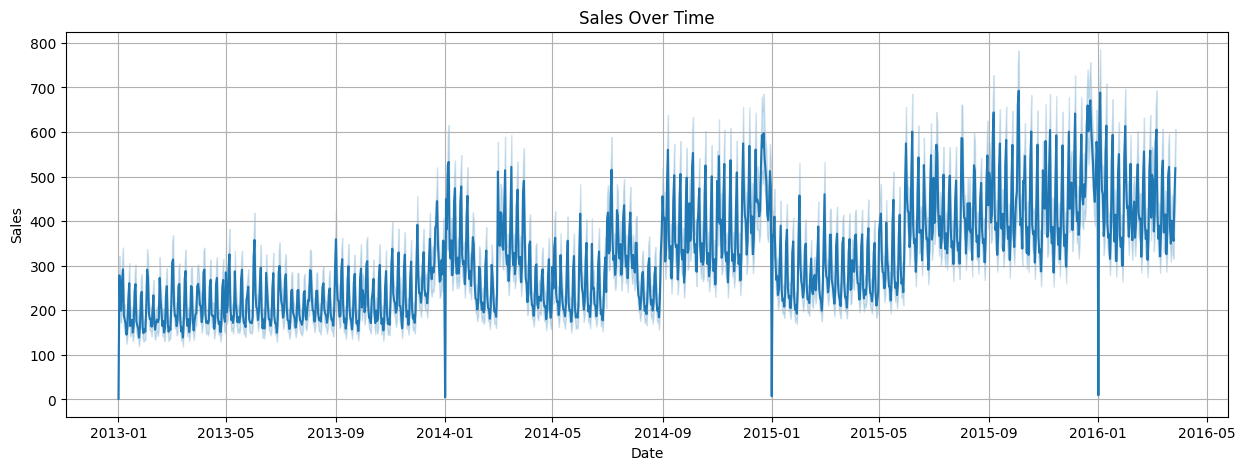

In [51]:
# Temporary dataframes for visualization
df_plot_train = df.iloc[:train_size].copy()
df_plot_val = df.iloc[train_size:train_size + val_size].copy()
df_plot_test = df.iloc[train_size + val_size:].copy()

# Ensure datetime format
df_plot_train['date'] = pd.to_datetime(df_plot_train['date'])
df_plot_val['date'] = pd.to_datetime(df_plot_val['date'])
df_plot_test['date'] = pd.to_datetime(df_plot_test['date'])

plot_sales_trend_over_time(df_plot_train)

Monthly Seasonality

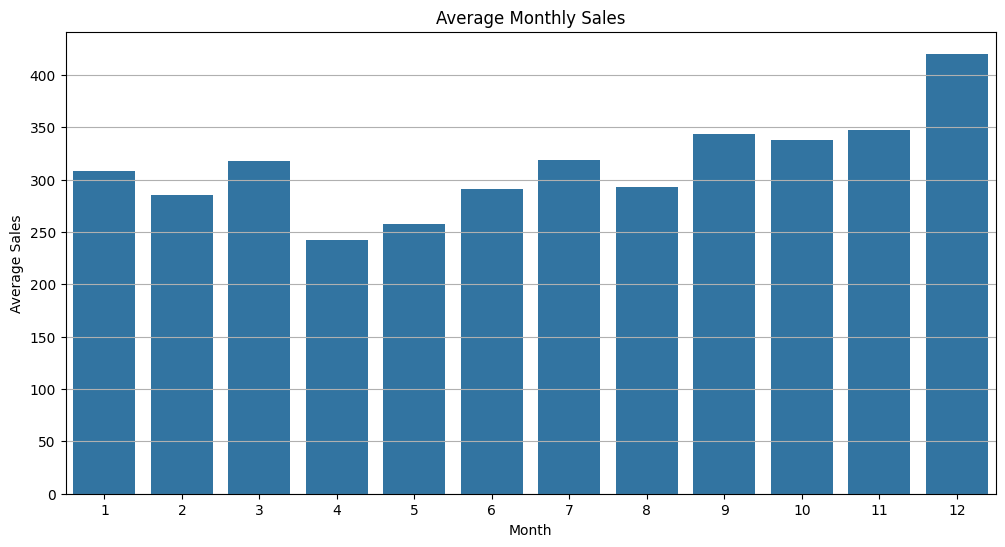

In [52]:
plot_average_monthly_sales(df_plot_train)

Weekly Seasonality

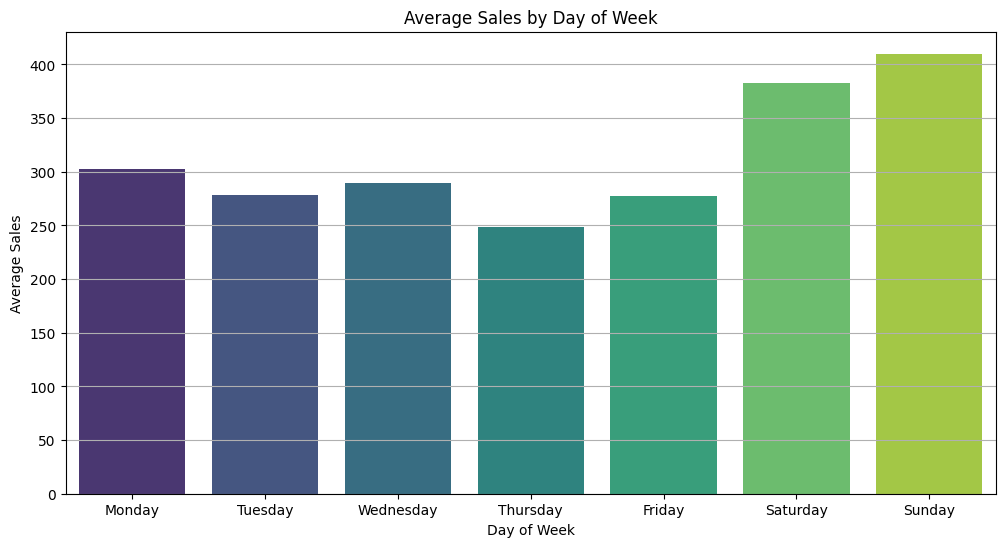

In [53]:
plot_average_sales_by_day_of_week(df_plot_train)

Impact of Promotions

In [54]:
promo_sales = df_plot_train[df_plot_train['onpromotion'] > 0]['sales'].mean()
no_promo_sales = df_plot_train[df_plot_train['onpromotion'] == 0]['sales'].mean()

print(f"Average sales with promotion: {promo_sales:.2f}")
print(f"Average sales without promotion: {no_promo_sales:.2f}")

Average sales with promotion: 1333.68
Average sales without promotion: 184.97


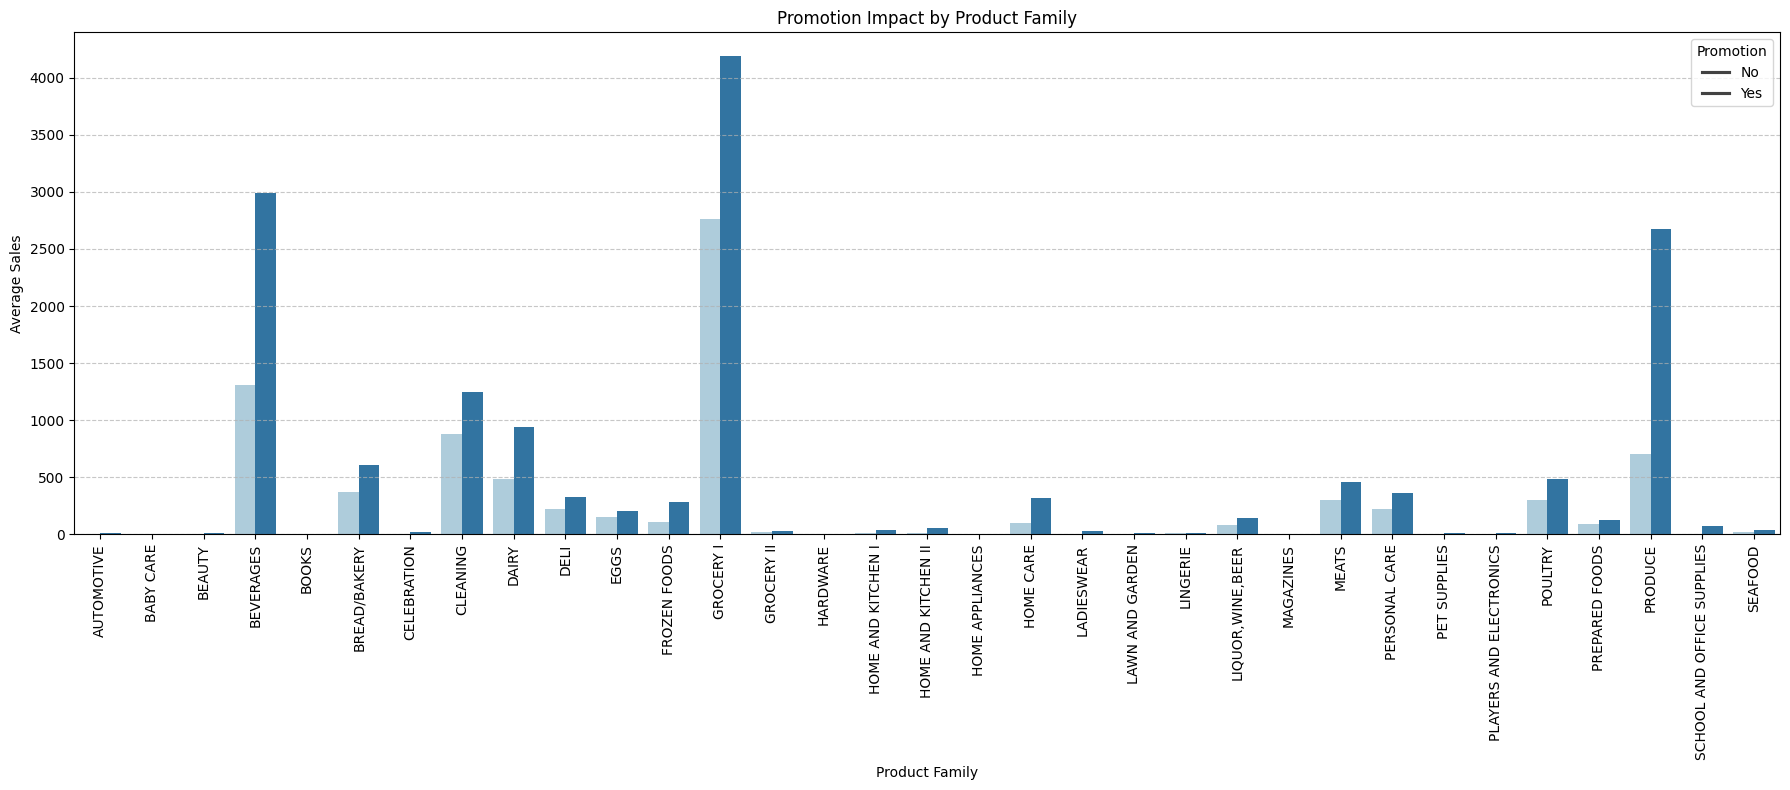

In [55]:
plot_promotion_impact_by_family(df_plot_train)

#### **1.4. Building the Complete Preprocessing Pipeline**

In [56]:
df['date'] = pd.to_datetime(df['date'])
df = (df.sort_values('date').reset_index(drop=True))

df_train, df_val, df_test = split_data(df, train_ratio=0.7, val_ratio=0.15)

df_train = create_time_features(df_train)
df_val = create_time_features(df_val)
df_test = create_time_features(df_test)

print(f"df_train columns with time features: {df_train.columns.tolist()}")

df_train = create_lag_features(df_train)
df_val = create_lag_features(df_val)
df_test = create_lag_features(df_test)

print(f"df_train lag features head:\n{df_train[[f'sales_lag_{i}' for i in range(1, 3)]].head()}")

df_train = create_rolling_mean_features(df_train)
df_val = create_rolling_mean_features(df_val)
df_test = create_rolling_mean_features(df_test)

print(f"df_train rolling mean features head:\n{df_train[[f'sales_rolling_mean_{i}' for i in [7, 14]]].head()}")

categorical_features = ['store_nbr', 'family']
df_train, df_val, df_test, encoder = one_hot_encode_and_concat(df_train, df_val,
                                                                        df_test, categorical_features)

numerical_features_to_scale = [
    'sales', 'onpromotion', 'year', 'month', 'day', 'weekday', 'dayofmonth',
    'sales_lag_1', 'sales_lag_2', 'sales_lag_3', 'sales_lag_4', 'sales_lag_5', 'sales_lag_6', 'sales_lag_7',
    'sales_lag_8', 'sales_lag_9', 'sales_lag_10', 'sales_lag_11', 'sales_lag_12', 'sales_lag_13', 'sales_lag_14',
    'sales_rolling_mean_7', 'sales_rolling_mean_14'
]
df_train, df_val, df_test, main_scaler = scale_data(df_train, df_val, df_test, numerical_features_to_scale)


print(f"df_train shape: {df_train.shape}")
print(f"df_val shape: {df_val.shape}")
print(f"df_test shape: {df_test.shape}")

+ Number of training samples: 2100621
+ Number of validation samples: 450133
+ Number of testing samples: 450134

Train: 2013-01-01 00:00:00 -> 2016-03-27 00:00:00
Validation: 2016-03-27 00:00:00 -> 2016-12-05 00:00:00
Test: 2016-12-05 00:00:00 -> 2017-08-15 00:00:00
df_train columns with time features: ['store_nbr', 'family', 'sales', 'onpromotion', 'year', 'month', 'day', 'weekday', 'dayofmonth']
df_train lag features head:
   sales_lag_1  sales_lag_2
0          0.0          0.0
1          0.0          0.0
2          0.0          0.0
3          0.0          0.0
4          0.0          0.0
df_train rolling mean features head:
   sales_rolling_mean_7  sales_rolling_mean_14
0                   0.0                    0.0
1                   0.0                    0.0
2                   0.0                    0.0
3                   0.0                    0.0
4                   0.0                    0.0
Shape of train: (2100621, 110)
Shape of validation: (450133, 110)
Shape of test: (4

/var/folders/gc/49grx5f90nv3f12yh4jhhf740000gn/T/ipykernel_99017/1377564777.py:10: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[-0.13021488 -0.13021488 -0.13021488 ... -0.13021488  0.41402879
 -0.13021488]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df_train_scaled.loc[:, feature] = scaler.fit_transform(df_train_scaled[[feature]])
/var/folders/gc/49grx5f90nv3f12yh4jhhf740000gn/T/ipykernel_99017/1377564777.py:11: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[ 1.41906955e-01 -1.30214876e-01  3.40736893e+00 ...  5.84603981e-03
  8.98586647e+00  8.22211533e-01]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df_val_scaled.loc[:, feature] = scaler.transform(df_val_scaled[[feature]])
/var/folders/gc/49grx5f90nv3f12yh4jhhf740000gn/T/ipykernel_99017/1377564777.py

df_train shape: (2100621, 110)
df_val shape: (450133, 110)
df_test shape: (450134, 110)


In [57]:
# Show info
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2100621 entries, 0 to 2100620
Columns: 110 entries, sales to family_SEAFOOD
dtypes: float64(110)
memory usage: 1.7 GB


In [103]:
# Show all the columns
columns_info = []
for col in df_train.columns:
    columns_info.append({'Column Name': col, 'Data Type': df_train[col].dtype})

df_columns_info = pd.DataFrame(columns_info)
print("Columns in df_train with their data types:")
print(df_columns_info.to_string()) # Using to_string() to display all rows without truncation

print(f"\nTotal number of columns: {len(df_train.columns)}")

Columns in df_train with their data types:
                           Column Name Data Type
0                                sales   float64
1                          onpromotion   float64
2                                 year   float64
3                                month   float64
4                                  day   float64
5                              weekday   float64
6                           dayofmonth   float64
7                          sales_lag_1   float64
8                          sales_lag_2   float64
9                          sales_lag_3   float64
10                         sales_lag_4   float64
11                         sales_lag_5   float64
12                         sales_lag_6   float64
13                         sales_lag_7   float64
14                         sales_lag_8   float64
15                         sales_lag_9   float64
16                        sales_lag_10   float64
17                        sales_lag_11   float64
18                        

#### **1.5. Sliding Window**

The **sliding window** (or rolling window) technique is a crucial method for transforming time series data into a format suitable for supervised learning models, especially Recurrent Neural Networks (RNNs) like LSTMs and GRUs. It works by creating sequences of past observations (the 'window') to predict a future observation.

**Raw time series (two features):**

| sales | onpromotion |
|-------|-------------|
| 10    | 0           |
| 12    | 1           |
| 15    | 0           |
| 18    | 1           |
| 20    | 0           |
| 25    | 1           |

**Sliding-window pairs (window_size=3):**

| Input (X)                            | Target (y) (sales)
|-------|-------------|
|`[[10, 0], [12, 1], [15, 0]]`            |18
|`[[12, 1], [15, 0], [18, 1]]   `         |20
|`[[15, 0], [18, 1], [20, 0]]   `         | 25

In [59]:
def create_time_series_datasets(df_train_input, df_val_input, df_test_input, selected_features, target_feature, window_size, batch_size):
    """
    Creates tf.data.Dataset objects for training, validation, and testing
    using tf.keras.utils.timeseries_dataset_from_array for memory efficiency.

    Args:
        df_train_input (pd.DataFrame): Preprocessed training DataFrame.
        df_val_input (pd.DataFrame): Preprocessed validation DataFrame.
        df_test_input (pd.DataFrame): Preprocessed test DataFrame.
        selected_features (list): List of feature column names.
        target_feature (str): Name of the target column.
        window_size (int): The size of the time window for input sequences.
        batch_size (int): The number of samples per batch in the datasets.

    Returns:
        tuple: (train_dataset, val_dataset, test_dataset)
    """
    # Prepare data for tf.keras.utils.timeseries_dataset_from_array
    train_features = df_train_input[selected_features].values
    train_target = df_train_input[target_feature].values

    val_features = df_val_input[selected_features].values
    val_target = df_val_input[target_feature].values

    test_features = df_test_input[selected_features].values
    test_target = df_test_input[target_feature].values

    # Create tf.data.Dataset for training
    train_dataset = tf.keras.utils.timeseries_dataset_from_array(
        data=train_features,
        targets=train_target[window_size:],  # Targets start after the first window
        sequence_length=window_size,
        sampling_rate=1,
        sequence_stride=1,
        shuffle=False,  # Do not shuffle time series data to maintain order
        batch_size=batch_size
    )

    # Create tf.data.Dataset for validation
    val_dataset = tf.keras.utils.timeseries_dataset_from_array(
        data=val_features,
        targets=val_target[window_size:],
        sequence_length=window_size,
        sampling_rate=1,
        sequence_stride=1,
        shuffle=False,
        batch_size=batch_size
    )

    # Create tf.data.Dataset for testing
    test_dataset = tf.keras.utils.timeseries_dataset_from_array(
        data=test_features,
        targets=test_target[window_size:],
        sequence_length=window_size,
        sampling_rate=1,
        sequence_stride=1,
        shuffle=False,
        batch_size=batch_size
    )

    return train_dataset, val_dataset, test_dataset

In [60]:
selected_features = [col for col in df_train.columns if col != 'sales']

window_size = 60
batch_size = 64

train_dataset, val_dataset, test_dataset = create_time_series_datasets(
    df_train, df_val, df_test, selected_features, 'sales', window_size, batch_size
)

for batch_x, batch_y in train_dataset.take(1):
    print(f"X_train batch shape: {batch_x.shape}")
    print(f"y_train batch shape: {batch_y.shape}")

print(f"Train batches: {len(train_dataset)}")
print(f"Validation batches: {len(val_dataset)}")
print(f"Test batches: {len(test_dataset)}")

X_train batch shape: (64, 60, 109)
y_train batch shape: (64,)
Train batches: 32822
Validation batches: 7033
Test batches: 7033


2026-06-20 22:17:05.341891: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [ ]:
# View the First Batch
# the model receives Days 1–60 as input and is asked to predict Day 61.
for X_batch, y_batch in train_dataset.take(1):

    first_window = pd.DataFrame(X_batch[0].numpy(), 
                                columns=selected_features)

    print("=== First 5 Time Steps ===")
    print(first_window.head())

    print("\n=== Last 5 Time Steps ===")
    print(first_window.tail())

    print("\n=== Target (Next Day Sales) ===")
    print(y_batch[0].numpy())

=== First 5 Time Steps ===
   onpromotion      year     month      day   weekday  dayofmonth  \
0    -0.130215 -1.215811 -1.467726 -1.66979 -1.000594    -1.66979   
1    -0.130215 -1.215811 -1.467726 -1.66979 -1.000594    -1.66979   
2    -0.130215 -1.215811 -1.467726 -1.66979 -1.000594    -1.66979   
3    -0.130215 -1.215811 -1.467726 -1.66979 -1.000594    -1.66979   
4    -0.130215 -1.215811 -1.467726 -1.66979 -1.000594    -1.66979   

   sales_lag_1  sales_lag_2  sales_lag_3  sales_lag_4  ...  family_MAGAZINES  \
0     -0.31839    -0.318392    -0.318392    -0.318391  ...               0.0   
1     -0.31839    -0.318392    -0.318392    -0.318391  ...               0.0   
2     -0.31839    -0.318392    -0.318392    -0.318391  ...               0.0   
3     -0.31839    -0.318392    -0.318392    -0.318391  ...               0.0   
4     -0.31839    -0.318392    -0.318392    -0.318391  ...               0.0   

   family_MEATS  family_PERSONAL CARE  family_PET SUPPLIES  \
0           0.0

#### **2. Training a Recurrent Neural Network**

A Recurrent Neural Network (RNN) is a type of artificial neural network that can process sequences of inputs, making them suitable for time series data. Unlike traditional feedforward neural networks, RNNs have connections that form directed cycles, allowing them to maintain an internal state (memory) that can capture information about past inputs.

In [61]:
# Determine number of input features automatically
num_features = len(selected_features)

# Define the SimpleRNN model
rnn_model = keras.Sequential([
    keras.layers.SimpleRNN(64, return_sequences=True, input_shape=(window_size, num_features)),
    keras.layers.SimpleRNN(64),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dropout(0.4),
    keras.layers.Dense(1)
])

rnn_model.compile(optimizer='adam', loss='mean_squared_error', metrics=['mae'])
rnn_model.summary()

/Users/macbook/.pyenv/versions/3.11.9/lib/python3.11/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 60, 64)         │        11,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 27,841 (108.75 KB)

 Trainable params: 27,841 (108.75 KB)

 Non-trainable params: 0 (0.00 B)

Training the Model

In [62]:
early_stopping_rnn = EarlyStopping(monitor='val_loss', 
                                   patience=2, restore_best_weights=True)

history_rnn = rnn_model.fit(train_dataset, validation_data=val_dataset, 
                            epochs=5, callbacks=[early_stopping_rnn])

Epoch 1/5
32822/32822 ━━━━━━━━━━━━━━━━━━━━ 863s 26ms/step - loss: 0.2991 - mae: 0.2286 - val_loss: 0.5168 - val_mae: 0.2578
Epoch 2/5
32822/32822 ━━━━━━━━━━━━━━━━━━━━ 990s 30ms/step - loss: 0.2322 - mae: 0.2008 - val_loss: 0.4664 - val_mae: 0.2399
Epoch 3/5
32822/32822 ━━━━━━━━━━━━━━━━━━━━ 782s 24ms/step - loss: 0.2171 - mae: 0.1937 - val_loss: 0.4717 - val_mae: 0.2348
Epoch 4/5
32822/32822 ━━━━━━━━━━━━━━━━━━━━ 786s 24ms/step - loss: 0.2099 - mae: 0.1906 - val_loss: 0.4355 - val_mae: 0.2346
Epoch 5/5
32822/32822 ━━━━━━━━━━━━━━━━━━━━ 1682s 51ms/step - loss: 0.2024 - mae: 0.1866 - val_loss: 0.4547 - val_mae: 0.2351


Visualizing Training Performance

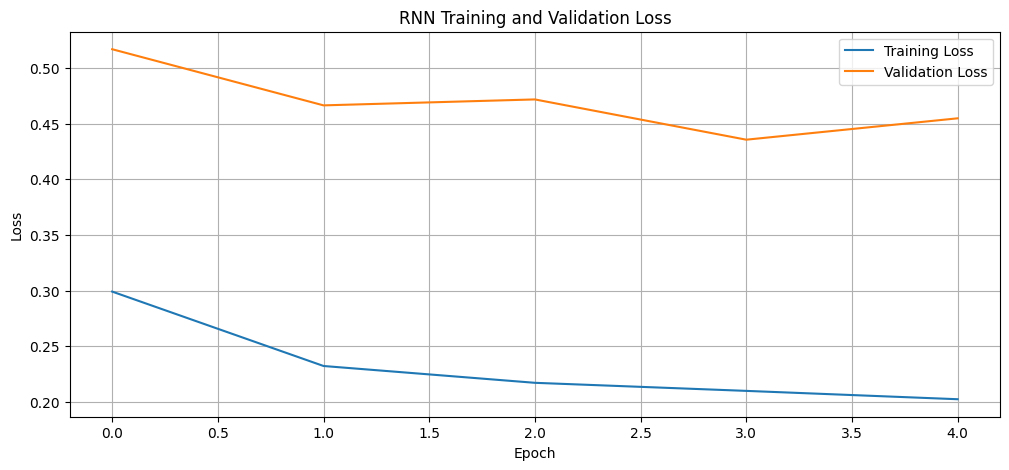

In [63]:
plot_training_validation_loss(history_rnn, title_prefix='RNN ')

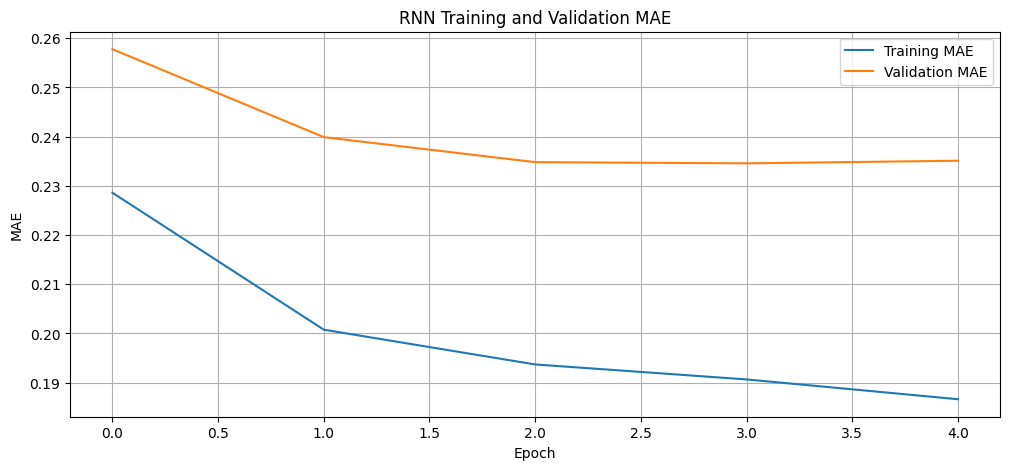

In [64]:
plot_training_validation_mae(history_rnn, title_prefix='RNN ')

Evaluating on the Test Set

In [65]:
y_pred_scaled_rnn = rnn_model.predict(test_dataset)

# Collect actual targets from tf.data.Dataset
y_test_scaled = np.concatenate([y.numpy() for _, y in test_dataset])

# Convert back to original sales values
y_test_actual = main_scaler.inverse_transform(y_test_scaled.reshape(-1, 1))
y_pred_actual = main_scaler.inverse_transform(y_pred_scaled_rnn)

mae_rnn = mean_absolute_error(y_test_actual, y_pred_actual)
mse_rnn = mean_squared_error(y_test_actual, y_pred_actual)
rmse_rnn = np.sqrt(mse_rnn)

print(f"Test MAE: {mae_rnn:.2f}")
print(f"Test MSE: {mse_rnn:.2f}")
print(f"Test RMSE: {rmse_rnn:.2f}")

7033/7033 ━━━━━━━━━━━━━━━━━━━━ 61s 9ms/step
Test MAE: 86.99
Test MSE: 50839.07
Test RMSE: 225.48


2026-06-20 23:43:27.014213: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Generating Predictions

In [66]:
y_pred_scaled = rnn_model.predict(test_dataset)

# Collect actual values from test_dataset
y_test_true_scaled_list = []
for _, batch_y_true in test_dataset:
    y_test_true_scaled_list.append(batch_y_true.numpy())

y_test_actual_scaled = np.concatenate(y_test_true_scaled_list).reshape(-1, 1)

7033/7033 ━━━━━━━━━━━━━━━━━━━━ 55s 8ms/step


Comparing Actual and Predicted Sales

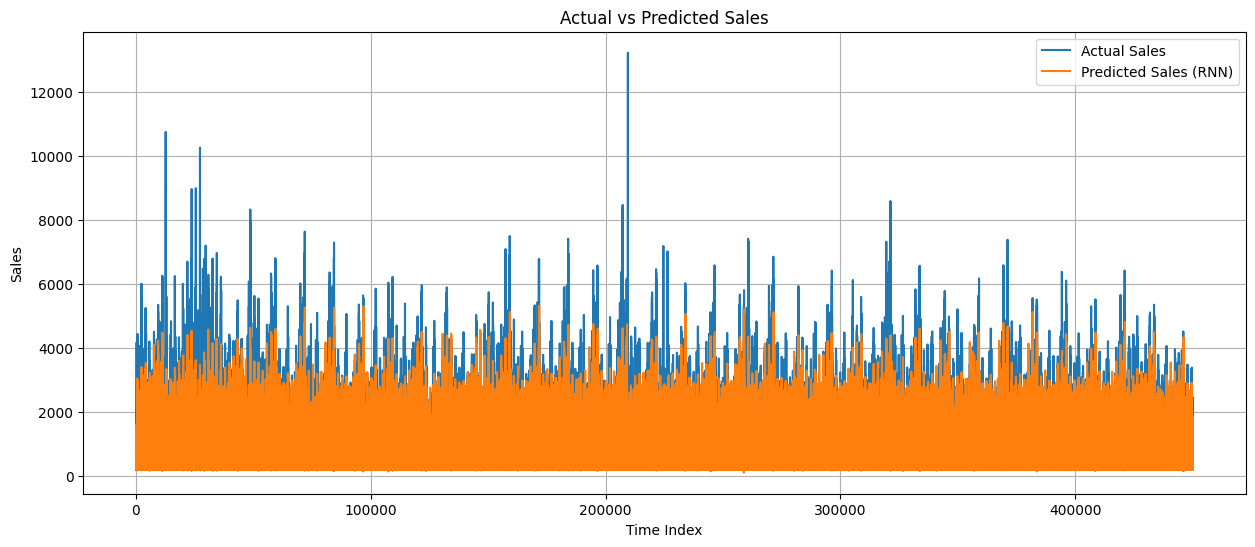

In [67]:
plot_actual_vs_predicted_sales(y_test_actual, y_pred_actual, label_predicted='Predicted Sales (RNN)')

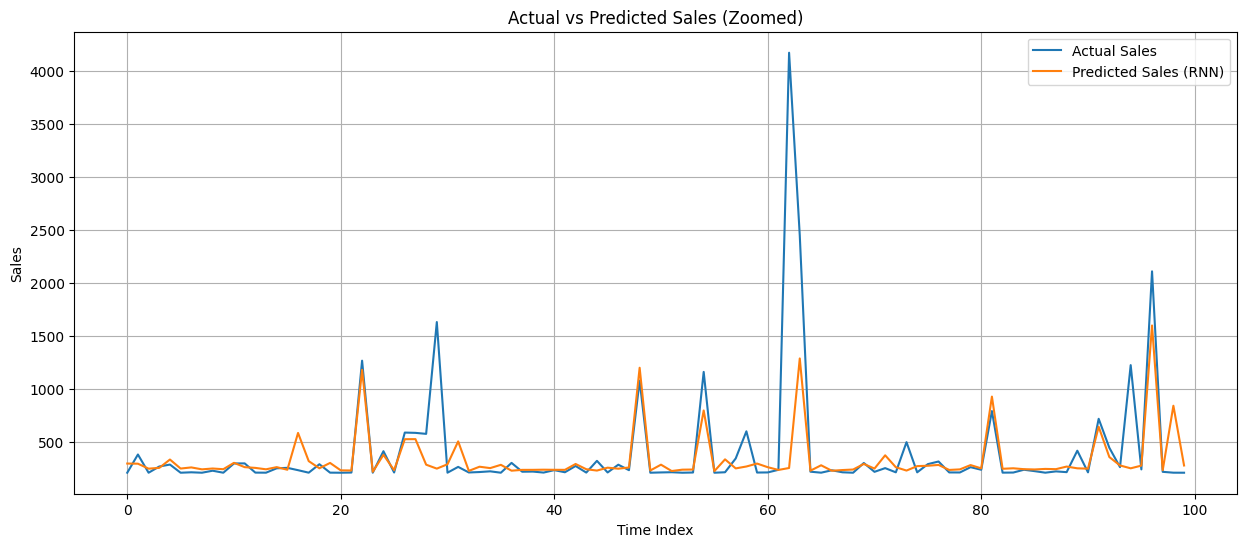

In [83]:
plot_actual_vs_predicted_sales_zoomed(y_test_actual, y_pred_actual, 200, 300, label_predicted='Predicted Sales (RNN)')

#### **3. Long Short-Term Memory**

Long Short-Term Memory (LSTM) networks are a special kind of RNN, capable of learning long-term dependencies. They were introduced to address the vanishing gradient problem that standard RNNs face. LSTMs have a more complex structure with 'gates' that control the flow of information, allowing them to selectively remember or forget information over long sequences. This makes them particularly effective for tasks like time series forecasting where long-range patterns are crucial.

In [68]:
train_dataset_lstm = train_dataset
val_dataset_lstm = val_dataset
test_dataset_lstm = test_dataset

In [69]:
# Define the model architecture
num_features = len(selected_features)

lstm_model = Sequential([
    LSTM(50, activation='relu', input_shape=(window_size, num_features), return_sequences=True),
    Dropout(0.2),
    LSTM(50, activation='relu'),
    Dropout(0.2),
    Dense(1)
])

# Compile and print structural details
lstm_model.compile(optimizer='adam', loss='mean_squared_error', metrics=['mae'])
lstm_model.summary()

/Users/macbook/.pyenv/versions/3.11.9/lib/python3.11/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 50)         │        32,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 60, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 52,251 (204.11 KB)

 Trainable params: 52,251 (204.11 KB)

 Non-trainable params: 0 (0.00 B)

In [72]:
early_stopping_lstm = EarlyStopping(monitor='val_loss', patience=2, 
                                    restore_best_weights=True)

In [73]:
history_lstm = lstm_model.fit(train_dataset_lstm, validation_data=val_dataset_lstm, 
                              epochs=5, callbacks=[early_stopping_lstm])

Epoch 1/5
32822/32822 ━━━━━━━━━━━━━━━━━━━━ 1847s 56ms/step - loss: 0.2281 - mae: 0.1915 - val_loss: 0.4281 - val_mae: 0.2142
Epoch 2/5
32822/32822 ━━━━━━━━━━━━━━━━━━━━ 1780s 54ms/step - loss: 0.1829 - mae: 0.1706 - val_loss: 0.3951 - val_mae: 0.1987
Epoch 3/5
32822/32822 ━━━━━━━━━━━━━━━━━━━━ 1879s 57ms/step - loss: 0.1658 - mae: 0.1618 - val_loss: 0.3630 - val_mae: 0.1892
Epoch 4/5
32822/32822 ━━━━━━━━━━━━━━━━━━━━ 2959s 90ms/step - loss: 0.1521 - mae: 0.1556 - val_loss: 0.3470 - val_mae: 0.1812
Epoch 5/5
32822/32822 ━━━━━━━━━━━━━━━━━━━━ 2579s 79ms/step - loss: 0.1448 - mae: 0.1512 - val_loss: 0.3352 - val_mae: 0.1754


Visualizing Training Loss

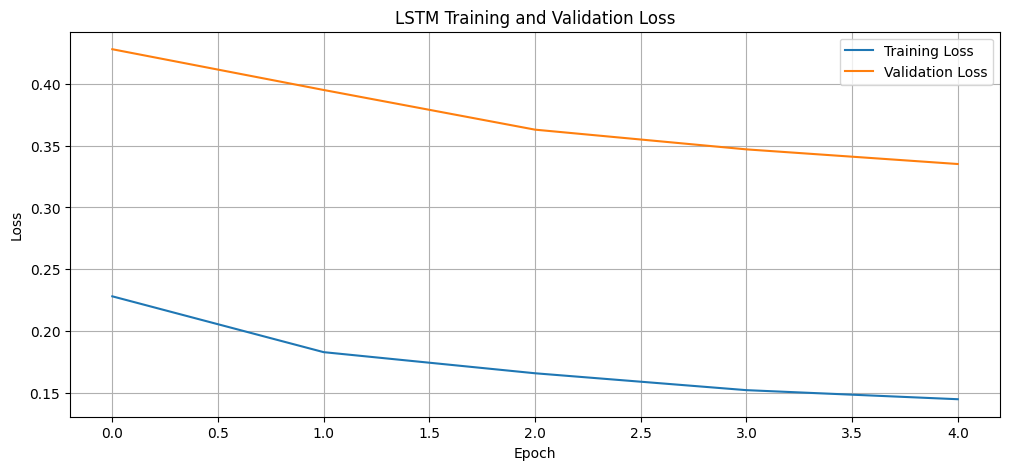

In [74]:
plot_training_validation_loss(history_lstm, title_prefix='LSTM ')

Visualizing MAE

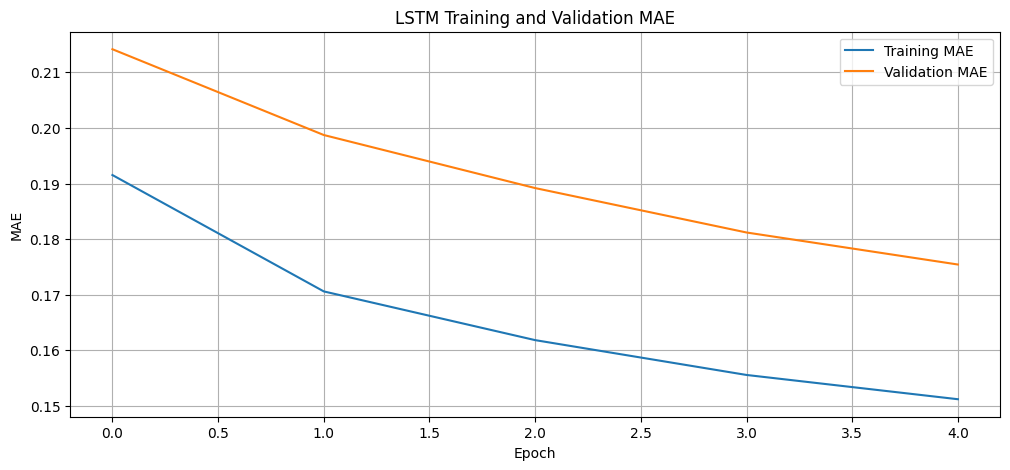

In [75]:
plot_training_validation_mae(history_lstm, title_prefix='LSTM ')

In [79]:
y_pred_scaled_lstm = lstm_model.predict(test_dataset_lstm)
y_test_scaled_lstm = np.concatenate([y.numpy() for _, y in test_dataset_lstm])

y_test_actual_lstm = (main_scaler.inverse_transform(y_test_scaled_lstm.reshape(-1, 1)))
y_pred_actual_lstm = (main_scaler.inverse_transform(y_pred_scaled_lstm))

mae_lstm = mean_absolute_error(y_test_actual_lstm, y_pred_actual_lstm)
mse_lstm = mean_squared_error(y_test_actual_lstm, y_pred_actual_lstm)
rmse_lstm = np.sqrt(mse_lstm)

print(f"LSTM Test MAE: {mae_lstm:.2f}")
print(f"LSTM Test MSE: {mse_lstm:.2f}")
print(f"LSTM Test RMSE: {rmse_lstm:.2f}")

7033/7033 ━━━━━━━━━━━━━━━━━━━━ 127s 18ms/step
LSTM Test MAE: 68.29
LSTM Test MSE: 35976.15
LSTM Test RMSE: 189.67


**Actual vs Predicted Sales**

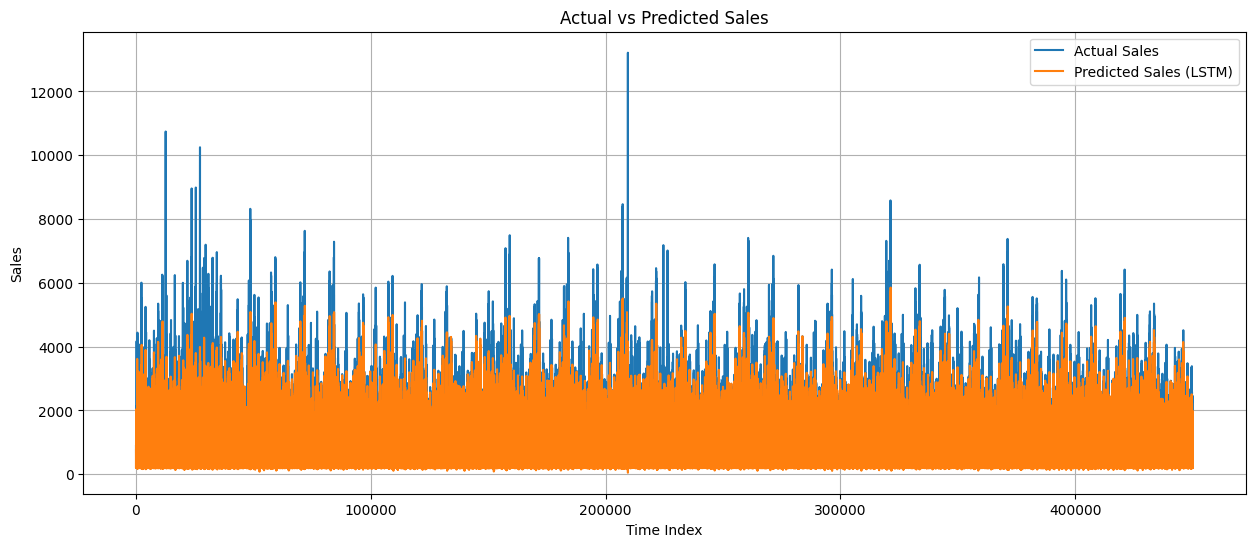

In [80]:
plot_actual_vs_predicted_sales(y_test_actual_lstm, y_pred_actual_lstm, label_predicted='Predicted Sales (LSTM)')

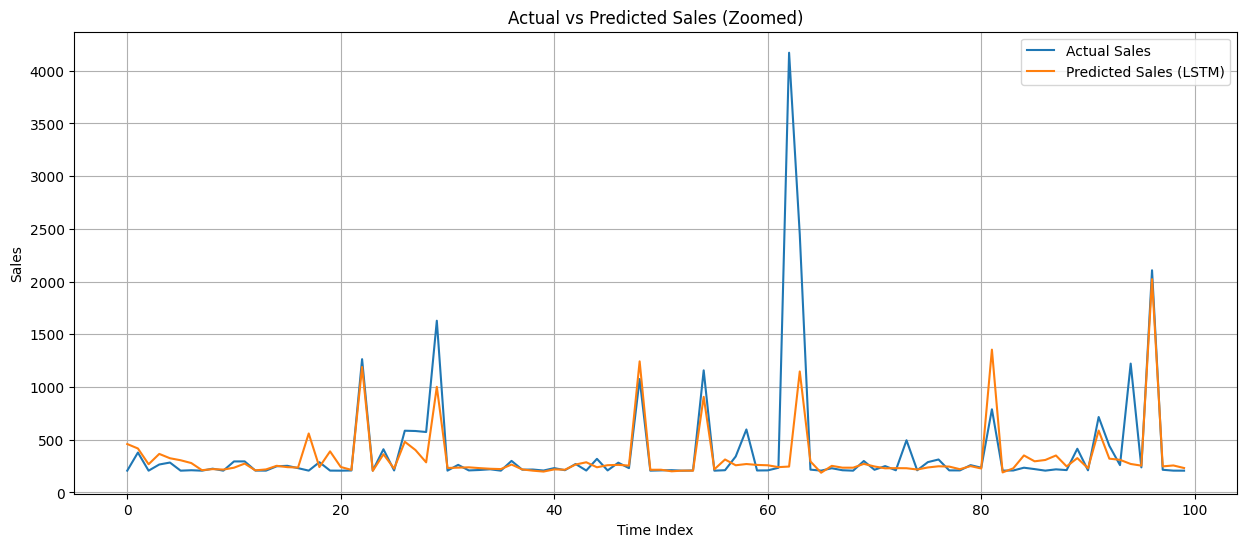

In [81]:
plot_actual_vs_predicted_sales_zoomed(y_test_actual_lstm, y_pred_actual_lstm, 200, 300, label_predicted='Predicted Sales (LSTM)')

#### **4. Gated Recurrent Unit (GRU)**

Gated Recurrent Unit (GRU) networks are a simpler variant of LSTMs that also address the vanishing gradient problem in standard RNNs. GRUs combine the forget and input gates into a single "update gate" and merge the cell state and hidden state, leading to a more streamlined architecture. While being less complex, GRUs often perform comparably to LSTMs on various tasks and can offer computational efficiency benefits.

In [99]:
train_dataset_gru = train_dataset
val_dataset_gru = val_dataset
test_dataset_gru = test_dataset

In [100]:
# Define the GRU model architecture
num_features = len(selected_features)

gru_model = Sequential([
    GRU(64, activation='relu', input_shape=(window_size, num_features), return_sequences=True),
    Dropout(0.2),
    GRU(64, activation='relu'),
    Dropout(0.2),
    Dense(1)
])

# Compile the GRU model
gru_model.compile(optimizer='adam', loss='mean_squared_error', metrics=['mae'])
gru_model.summary()

/Users/macbook/.pyenv/versions/3.11.9/lib/python3.11/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru_2 (GRU)                     │ (None, 60, 64)         │        33,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 60, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_3 (GRU)                     │ (None, 64)             │        24,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 58,625 (229.00 KB)

 Trainable params: 58,625 (229.00 KB)

 Non-trainable params: 0 (0.00 B)

In [101]:
early_stopping_gru = EarlyStopping(monitor='val_loss',
                                patience=2,
                                restore_best_weights=True)

history_gru = gru_model.fit(train_dataset_gru,
                            epochs=5, batch_size=64,
                            validation_data=val_dataset_gru,
                            callbacks=[early_stopping_gru])

Epoch 1/5
32822/32822 ━━━━━━━━━━━━━━━━━━━━ 2322s 71ms/step - loss: 0.2750 - mae: 0.2123 - val_loss: 0.4733 - val_mae: 0.2389
Epoch 2/5
32822/32822 ━━━━━━━━━━━━━━━━━━━━ 2310s 70ms/step - loss: 0.1920 - mae: 0.1761 - val_loss: 0.3973 - val_mae: 0.2006
Epoch 3/5
32822/32822 ━━━━━━━━━━━━━━━━━━━━ 2308s 70ms/step - loss: 0.1682 - mae: 0.1641 - val_loss: 0.3739 - val_mae: 0.1948
Epoch 4/5
32822/32822 ━━━━━━━━━━━━━━━━━━━━ 3693s 113ms/step - loss: 0.1560 - mae: 0.1587 - val_loss: 0.3674 - val_mae: 0.1948
Epoch 5/5
32822/32822 ━━━━━━━━━━━━━━━━━━━━ 2355s 72ms/step - loss: 0.1520 - mae: 0.1571 - val_loss: 0.3460 - val_mae: 0.1879


Visualizing GRU Training Loss

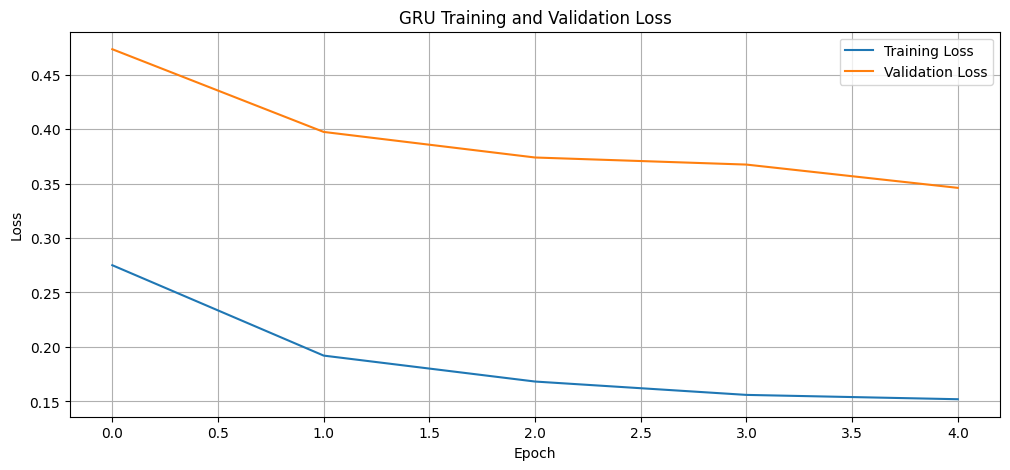

In [104]:
plot_training_validation_loss(history_gru, title_prefix='GRU ')

Visualizing GRU MAE

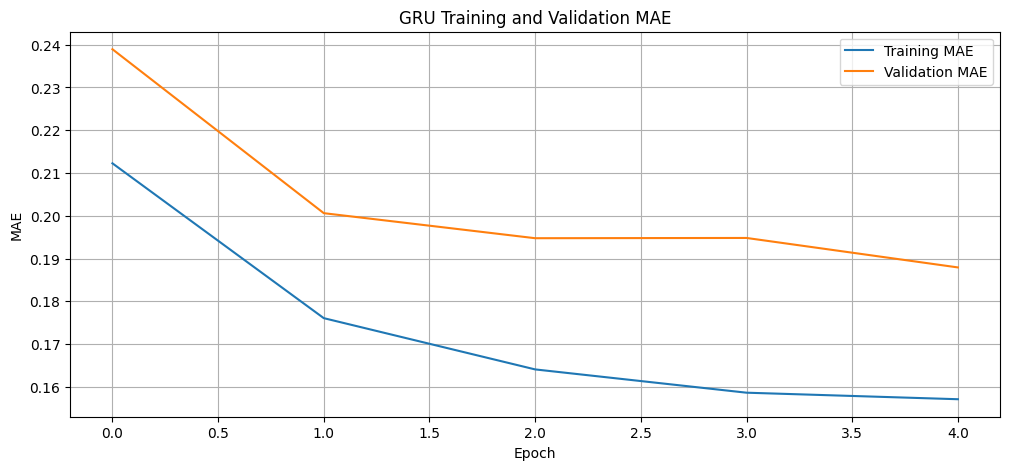

In [105]:
plot_training_validation_mae(history_gru, title_prefix='GRU ')

Evaluating GRU on the Test Set

In [106]:
y_pred_scaled_gru = gru_model.predict(test_dataset_gru)

y_test_scaled_gru = np.concatenate([y.numpy() for _, y in test_dataset_gru])
y_test_actual_gru = (main_scaler.inverse_transform(y_test_scaled_gru.reshape(-1, 1)))
y_pred_actual_gru = (main_scaler.inverse_transform(y_pred_scaled_gru))

mae_gru = mean_absolute_error(y_test_actual_gru, y_pred_actual_gru)
mse_gru = mean_squared_error(y_test_actual_gru, y_pred_actual_gru)

rmse_gru = np.sqrt(mse_gru)

print(f"GRU Test MAE: {mae_gru:.2f}")
print(f"GRU Test MSE: {mse_gru:.2f}")
print(f"GRU Test RMSE: {rmse_gru:.2f}")

7033/7033 ━━━━━━━━━━━━━━━━━━━━ 136s 19ms/step
GRU Test MAE: 71.98
GRU Test MSE: 36754.51
GRU Test RMSE: 191.71


Actual vs Predicted Sales (GRU)

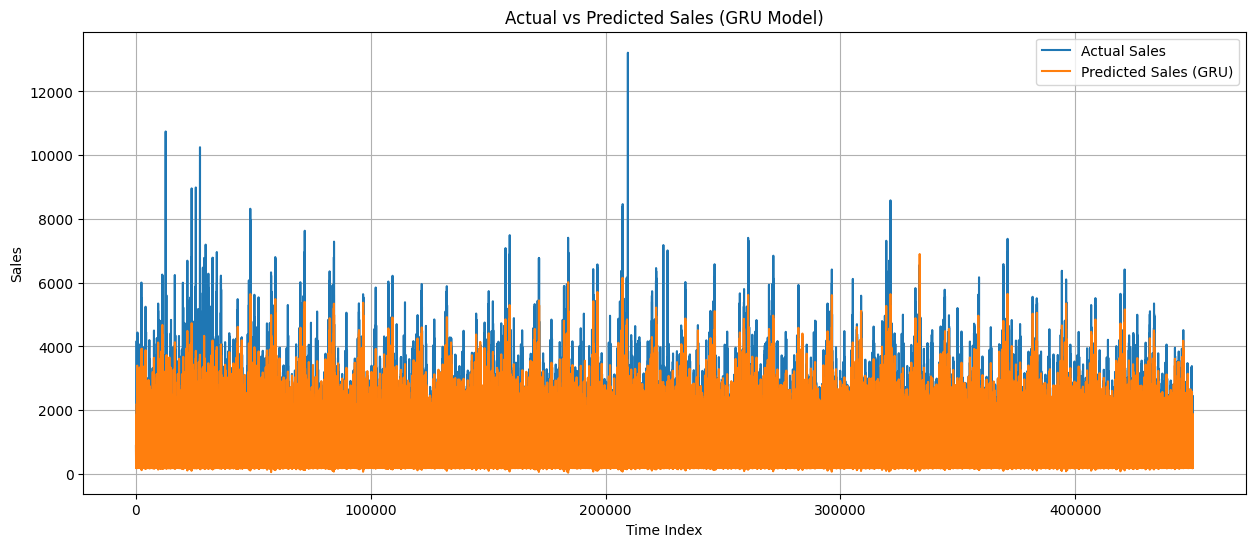

In [107]:
plot_actual_vs_predicted_sales(y_test_actual_gru, y_pred_actual_gru, title='Actual vs Predicted Sales (GRU Model)', label_predicted='Predicted Sales (GRU)')

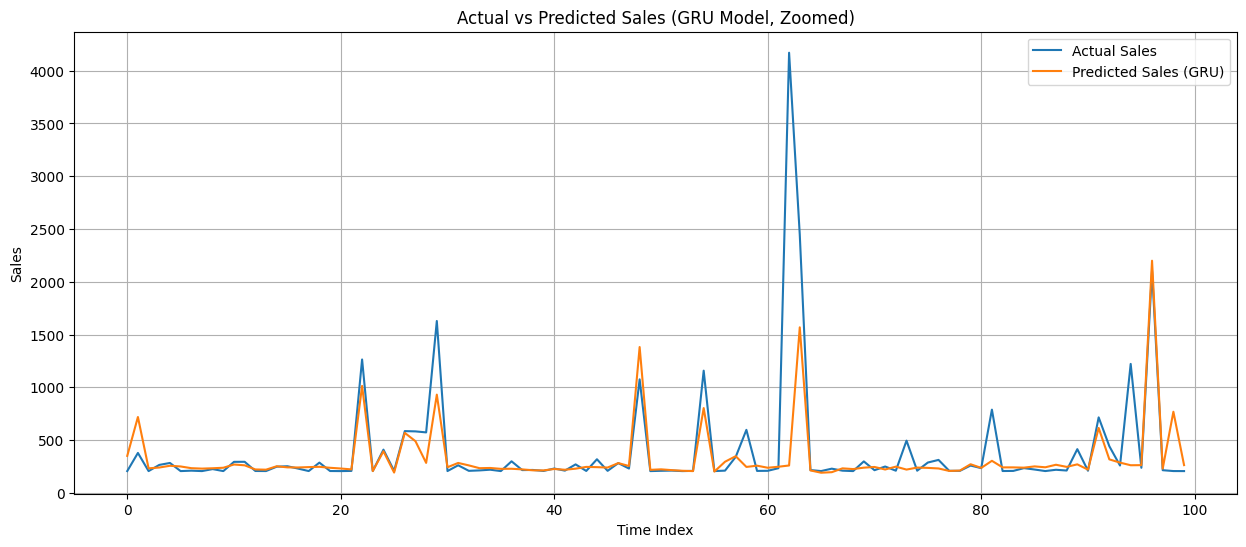

In [108]:
plot_actual_vs_predicted_sales_zoomed(y_test_actual_gru, y_pred_actual_gru, 200, 300, title='Actual vs Predicted Sales (GRU Model, Zoomed)', label_predicted='Predicted Sales (GRU)')

#### **5. Baseline Model**

A **baseline model** is a simple model that provides a reference point for evaluating the performance of more complex models. It's often the simplest possible model that can make a prediction, usually by using heuristics or basic statistics.

***Idea and Approach***

The core idea behind a baseline model is to establish a minimal level of performance that any new, more sophisticated model should aim to surpass. For time series forecasting, a common baseline approach is the "Naive" or "Persistence" model, where the prediction for the next time step is simply the value from the previous time step. This approach assumes that recent past values are the best indicators of immediate future values.

***Rule of Thumb***

When evaluating predictive models, the baseline serves a critical role:

- **If a neural network or other complex model cannot significantly outperform the baseline, it is not providing meaningful additional value.** In such cases, the added complexity, computational cost, and potential for overfitting are not justified, and the simpler baseline model might be preferred.
- **If a complex model significantly improves upon the baseline, the additional complexity may be justified.** A substantial improvement in metrics (like reduced MAE or RMSE) indicates that the more advanced model is capturing patterns that the baseline cannot, making its use worthwhile.

In [84]:
# Baseline Model: Predict with previous day's sales (sales_lag_1)
# Find the index of 'sales_lag_1' in selected_features. This assumes 'sales_lag_1' is present.
# Locate sales_lag_1 among the input features
try:
    sales_lag_1_feature_index = selected_features.index('sales_lag_1')
except ValueError:
    print("Warning: sales_lag_1 not found.")
    sales_lag_1_feature_index = 0


baseline_predictions = []
baseline_targets = []

for batch_x, batch_y in test_dataset:
    baseline_predictions.extend(batch_x[:, -1, sales_lag_1_feature_index].numpy())
    baseline_targets.extend(batch_y.numpy())

baseline_predictions = np.array(baseline_predictions)
baseline_targets = np.array(baseline_targets)

In [85]:
y_pred_actual_baseline = (main_scaler.inverse_transform(baseline_predictions.reshape(-1, 1)))
y_test_actual_baseline = (main_scaler.inverse_transform(baseline_targets.reshape(-1, 1)))

In [ ]:
mae_baseline = mean_absolute_error(y_test_actual_baseline, y_pred_actual_baseline)
mse_baseline = mean_squared_error(y_test_actual_baseline, y_pred_actual_baseline)
rmse_baseline = np.sqrt(mse_baseline)

print("--- Previous-Day Sales Baseline ---")
print(f"Test MAE: {mae_baseline:.2f}")
print(f"Test MSE: {mse_baseline:.2f}")
print(f"Test RMSE: {rmse_baseline:.2f}")


--- Previous-Day Sales Baseline ---
Test MAE: 273.51
Test MSE: 421196.79
Test RMSE: 649.00


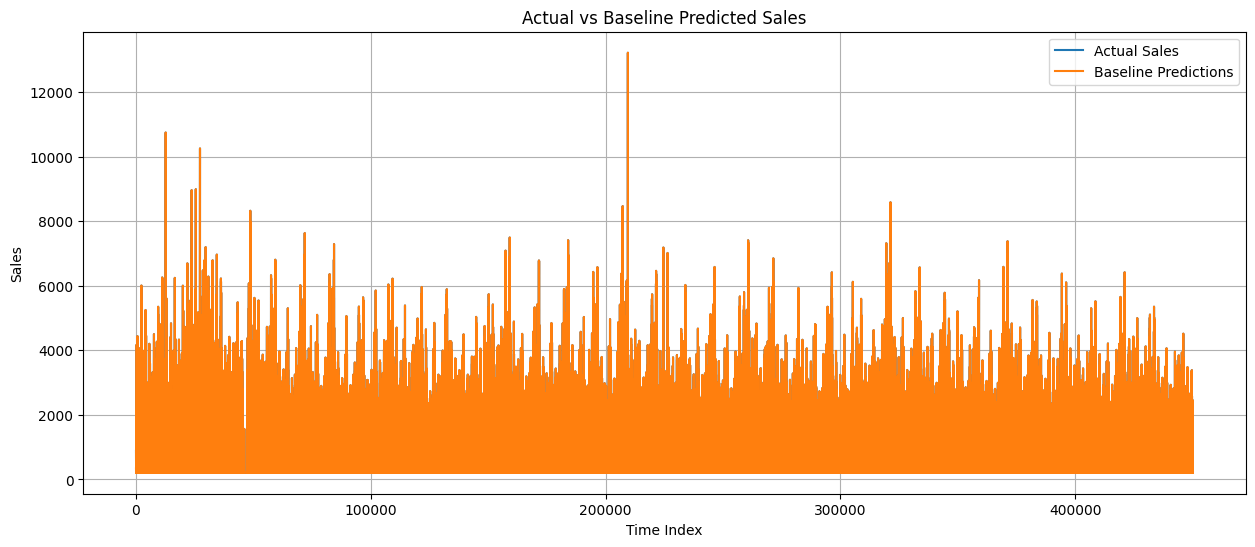

In [87]:
plot_actual_vs_predicted_sales(y_test_actual_baseline, y_pred_actual_baseline, title='Actual vs Baseline Predicted Sales', label_predicted='Baseline Predictions')

#### **6. Model Comparison**

The table below summarizes the final performance metrics for all three recurrent architectures evaluated. This comparison helps identify which model better captured the complex patterns in the store sales data.

| Model | Final Training Loss | Final Validation Loss | Final Training MAE | Final Validation MAE |
| :--- | :--- | :--- | :--- | :--- |
| Simple RNN | 0.202384 | 0.454728 | 0.186625 | 0.235098 |
| LSTM | 0.144782 | 0.335191 | 0.151197 | 0.175430 |
| GRU | 0.152001 | 0.346013 | 0.157125 | 0.187927 |